# Comprehensive Feature Selection for Delinquency Prediction

This notebook implements a **multi-stage feature selection pipeline** optimized for tree-based models:

1. **Variance Threshold** - Remove low-variance features
2. **Correlation Filtering** - Remove highly correlated features
3. **Tree-Based Feature Importance** - Rank by model importance
4. **Mutual Information** - Capture non-linear relationships
5. **SHAP Values** - Understand feature contributions
6. **Permutation Importance** - Real predictive power
7. **Stability Selection** - Choose robust features

**Goal**: Identify the most predictive and stable features for delinquency risk.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Imports complete!")

Imports complete!


In [2]:
# ── Configuration ────────────────────────────────────────────────
# Change DATASET to switch between populations.
# "filtered"  → uses filtered_features.csv  (scoring exclusions applied)
# "all"       → uses features.csv           (full population)
DATASET = "filtered"  

# Derived paths — everything below updates automatically
INPUT_CSV     = f"../output/{DATASET}_features.csv" if DATASET != "all" else "../output/features.csv"
OUTPUT_PREFIX = f"../output/{DATASET}_"             if DATASET != "all" else "../output/"

print(f"Dataset  : {DATASET}")
print(f"Input    : {INPUT_CSV}")
print(f"Output   : {OUTPUT_PREFIX}*")

Dataset  : filtered
Input    : ../output/filtered_features.csv
Output   : ../output/filtered_*


## Load and Prepare Data

**Note:** Features are pre-computed and loaded from `features.csv` for speed.

In [3]:
# Load features from CSV
print("Loading features from CSV...")
features_df = pd.read_csv(INPUT_CSV, index_col=0)

print(f"\nTotal features: {features_df.shape[1] - 1}")
print(f"Total consumers: {features_df.shape[0]}")
print(f"Null DQ_TARGETs: {features_df['DQ_TARGET'].isnull().sum()}")
print(f"Delinquency rate: {features_df['DQ_TARGET'].mean():.2%}")
print("\nFeatures loaded successfully!")

Loading features from CSV...

Total features: 257
Total consumers: 13418
Null DQ_TARGETs: 2664
Delinquency rate: 8.18%

Features loaded successfully!


In [4]:
# Prepare X and y
df_clean = features_df[features_df["DQ_TARGET"].notna()].copy()
y = df_clean["DQ_TARGET"].astype(int)
X = df_clean.drop(columns=["DQ_TARGET"]).select_dtypes(include=[np.number]).fillna(0)

print(f"X shape: {X.shape}")
print(f"y distribution: {y.value_counts().to_dict()}")

# Train/val split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}")

X shape: (10754, 257)
y distribution: {0: 9874, 1: 880}

Train: (8065, 257), Val: (2689, 257)


## Stage 1: Variance Threshold

Remove features with very low variance (near-constant values).

In [5]:
from sklearn.feature_selection import VarianceThreshold

# Remove features with < 1% variance
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_train)

features_stage1 = X_train.columns[selector_var.get_support()].tolist()
removed_var = set(X_train.columns) - set(features_stage1)

print(f"Features removed (low variance): {len(removed_var)}")
print(f"Features remaining: {len(features_stage1)}")

if removed_var:
    print(f"\nRemoved: {list(removed_var)[:10]}...")

X_train_s1 = X_train[features_stage1]
X_val_s1 = X_val[features_stage1]

Features removed (low variance): 3
Features remaining: 254

Removed: ['revolving_debt__n_accounts', 'tx__max_debit__all', 'debit__total__all']...


## Stage 2: Correlation Filtering

Remove highly correlated features (keep one from each correlated group).

In [6]:
# Calculate correlation matrix
corr_matrix = X_train_s1.corr().abs()

# Find pairs of highly correlated features
threshold_corr = 0.95
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > threshold
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

print(f"Features removed (high correlation > {threshold_corr}): {len(to_drop_corr)}")
if to_drop_corr:
    print(f"Examples: {to_drop_corr[:5]}")

features_stage2 = [f for f in features_stage1 if f not in to_drop_corr]
print(f"Features remaining: {len(features_stage2)}")

X_train_s2 = X_train_s1[features_stage2]
X_val_s2 = X_val_s1[features_stage2]

Features removed (high correlation > 0.95): 60
Examples: ['balance__pct_below_100__all', 'balance__mean__60d', 'balance__min__60d', 'balance__pct_negative__60d', 'n_tx__60d']
Features remaining: 194


## Stage 3: Baseline Model Performance

Train a baseline model to establish performance before further selection.

In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Baseline model with all remaining features
# Using GradientBoostingClassifier which has feature_importances_ attribute
model_baseline = GradientBoostingClassifier(
    max_depth=6,
    n_estimators=300,
    learning_rate=0.05,
    min_samples_leaf=50,
    random_state=42,
    subsample=0.8,
    verbose=1
)

model_baseline.fit(X_train_s2, y_train)

y_val_prob = model_baseline.predict_proba(X_val_s2)[:, 1]
y_val_pred = model_baseline.predict(X_val_s2)

baseline_auc = roc_auc_score(y_val, y_val_prob)

print("="*60)
print("BASELINE MODEL PERFORMANCE")
print("="*60)
print(f"Features used: {X_train_s2.shape[1]}")
print(f"Validation AUC: {baseline_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.5466           0.0125           59.16s
         2           0.5361           0.0209           58.18s
         3           0.5252           0.0149           59.65s
         4           0.5196           0.0292           58.96s
         5           0.5099           0.0098           58.89s
         6           0.4920          -0.0317           58.39s
         7           0.4822          -0.0030           57.93s
         8           0.4872           0.0559           57.65s
         9           0.4796           0.0008           57.16s
        10           0.4726           0.0064           57.10s
        20           0.4187          -0.0396           54.42s
        30           0.3880          -0.0186           52.89s
        40           0.3626          -0.0021           50.62s
        50           0.3493           0.0333           48.78s
        60           0.3331           0.0144           46.98s
       

## Stage 4: Tree-Based Feature Importance

Use built-in feature importance from gradient boosting.

Top 20 Features by Tree Importance:
                               feature  importance
176     consumer_balance__total_liquid    0.055824
7           account__history_days__all    0.052920
5          balance__pct_below_500__all    0.049832
149       essentials_spend__total__all    0.033591
119                  cat_1__cat_n__90d    0.018407
162                    total_fees__90d    0.018203
177      consumer_balance__mean_liquid    0.015051
15                           n_tx__30d    0.013988
173        paycheck__consistency_score    0.013652
94           cat_4__cat_net_total__90d    0.012510
103         cat_19__cat_net_total__90d    0.012448
39          cat_13__cat_net_total__all    0.011774
178       consumer_balance__min_liquid    0.011645
150    discretionary_spend__total__all    0.011093
152  discretionary__pct_of_income__all    0.011009
6                          n_days__all    0.010850
161                    total_fees__30d    0.010709
148                 income__total__all    0.01

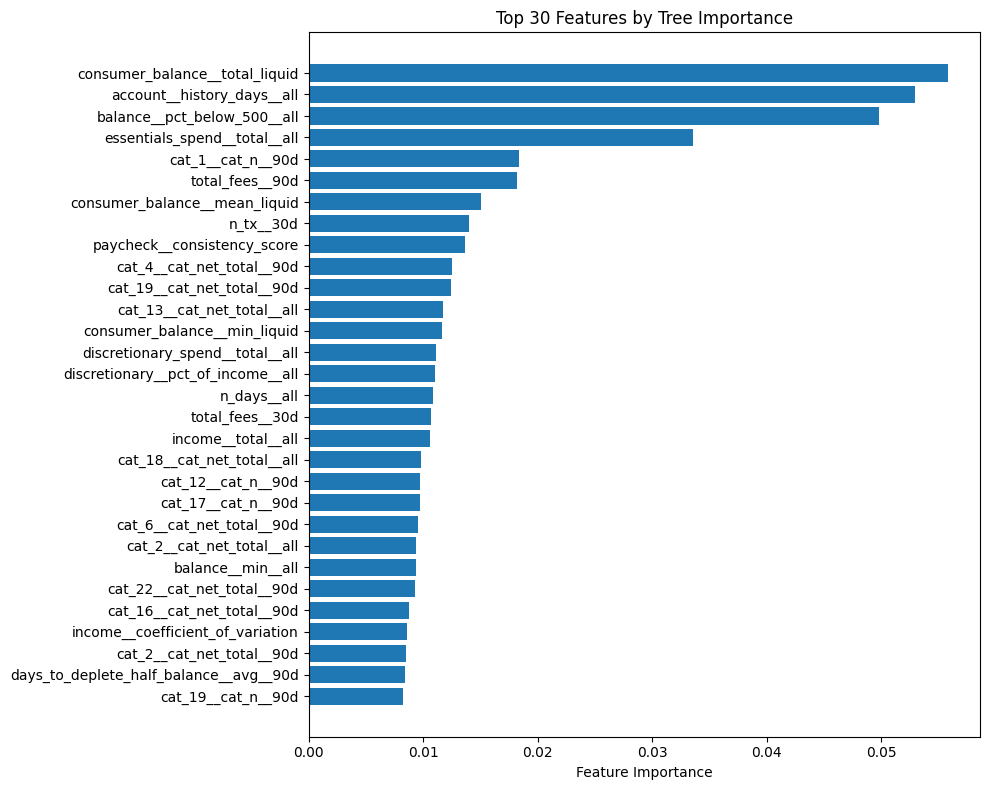

In [8]:
# Get feature importances
importance_df = pd.DataFrame({
    'feature': X_train_s2.columns,
    'importance': model_baseline.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Features by Tree Importance:")
print(importance_df.head(20).to_string())

# Plot top 30
plt.figure(figsize=(10, 8))
top_30 = importance_df.head(30)
plt.barh(range(len(top_30)), top_30['importance'])
plt.yticks(range(len(top_30)), top_30['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 30 Features by Tree Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Stage 5: Permutation Importance

Measure the actual impact on model performance when features are shuffled.

Computing permutation importance (this may take a few minutes)...

Top 20 Features by Permutation Importance:
                            feature  importance_mean  importance_std
7        account__history_days__all         0.034710        0.004071
176  consumer_balance__total_liquid         0.027729        0.007355
5       balance__pct_below_500__all         0.015829        0.003894
126              cat_12__cat_n__90d         0.010396        0.001474
38       cat_12__cat_net_total__all         0.008910        0.000810
119               cat_1__cat_n__90d         0.008084        0.003216
190        savings__balance__latest         0.006949        0.002032
130              cat_17__cat_n__90d         0.006812        0.001660
149    essentials_spend__total__all         0.004578        0.002748
162                 total_fees__90d         0.004113        0.001735
132              cat_19__cat_n__90d         0.003814        0.001220
23        cashflow__volatility__90d         0.003596        0.

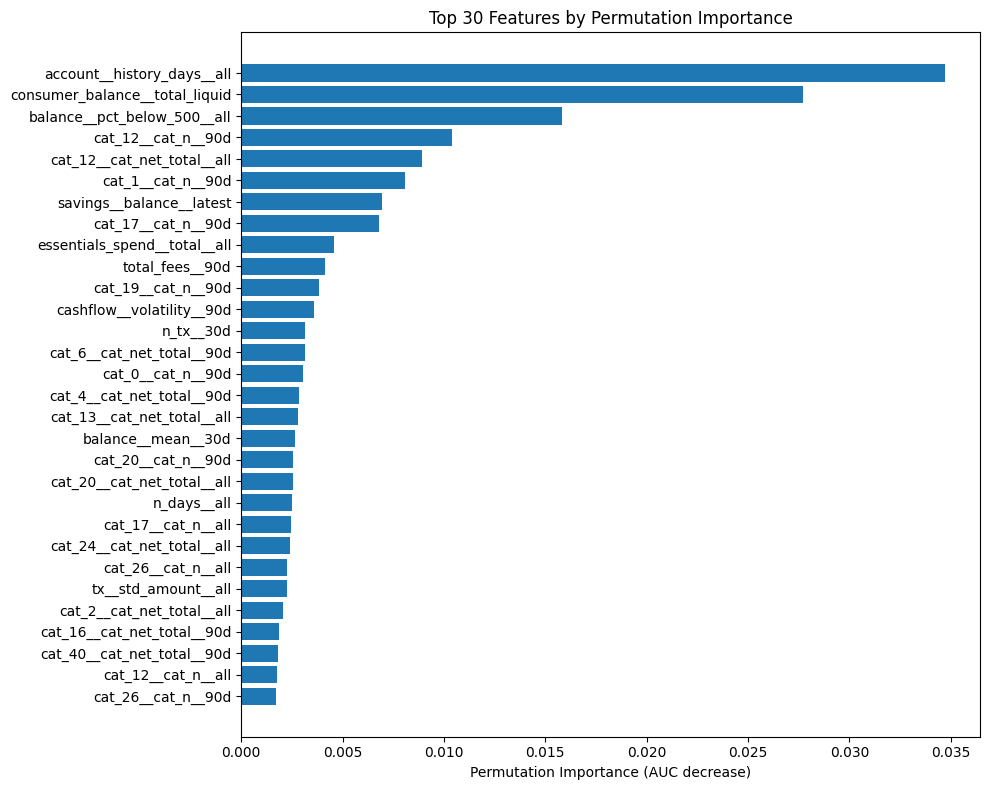

In [9]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance (this may take a few minutes)...")

perm_importance = permutation_importance(
    model_baseline, 
    X_val_s2, 
    y_val,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': X_train_s2.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop 20 Features by Permutation Importance:")
print(perm_importance_df.head(20).to_string())

# Plot
plt.figure(figsize=(10, 8))
top_30_perm = perm_importance_df.head(30)
plt.barh(range(len(top_30_perm)), top_30_perm['importance_mean'])
plt.yticks(range(len(top_30_perm)), top_30_perm['feature'])
plt.xlabel('Permutation Importance (AUC decrease)')
plt.title('Top 30 Features by Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Stage 6: SHAP Values

Use SHAP to understand feature contributions and interactions.

Computing SHAP values (this may take several minutes)...

Top 5 Features by SHAP Importance:
                            feature  shap_importance
176  consumer_balance__total_liquid         0.376137
7        account__history_days__all         0.338732
5       balance__pct_below_500__all         0.163133
190        savings__balance__latest         0.121731
119               cat_1__cat_n__90d         0.121033


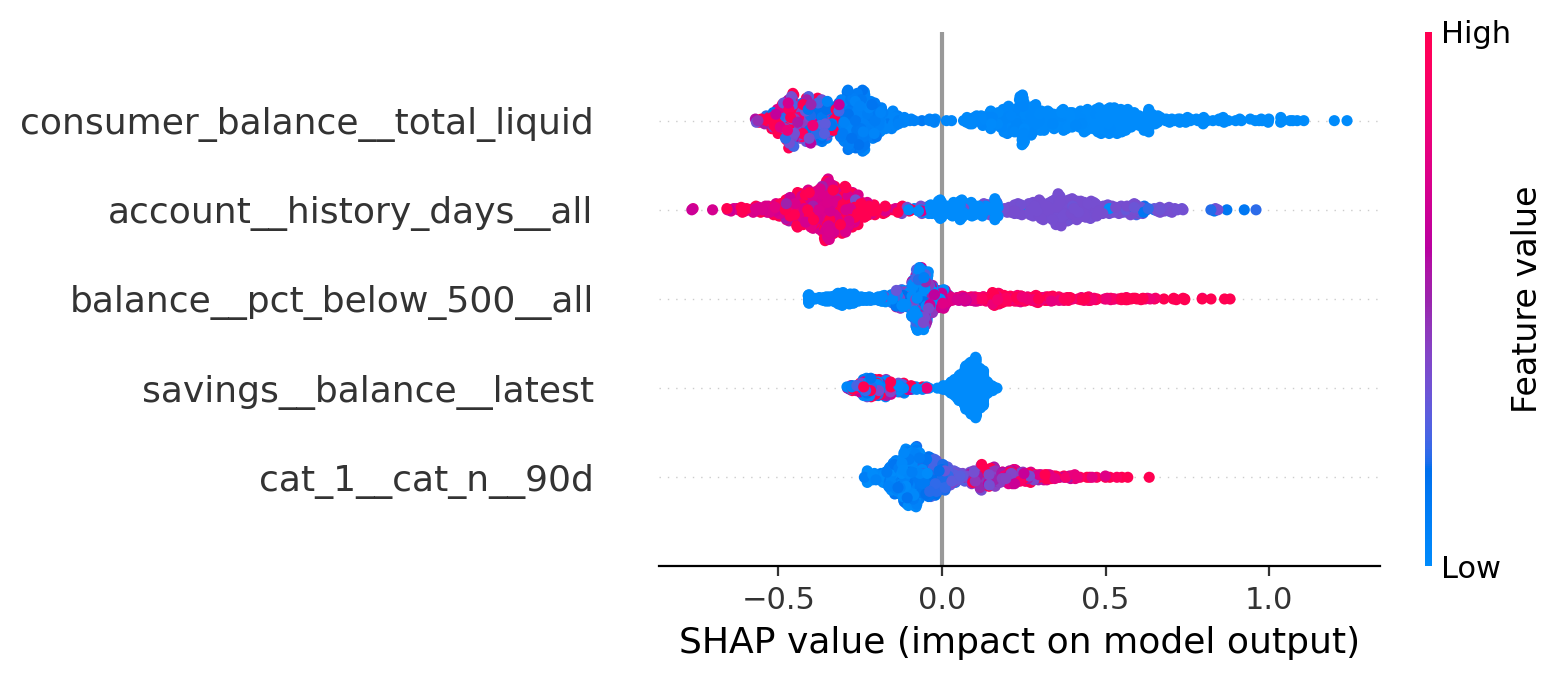

In [17]:
try:
    import shap
    
    print("Computing SHAP values (this may take several minutes)...")
    
    # Sample for faster computation
    sample_size = min(1000, len(X_val_s2))
    X_val_sample = X_val_s2.sample(n=sample_size, random_state=42)
    
    # Create explainer
    explainer = shap.TreeExplainer(model_baseline)
    shap_values = explainer.shap_values(X_val_sample)
    
    # If binary classification, take positive class
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # Calculate mean absolute SHAP values
    shap_importance = pd.DataFrame({
        'feature': X_val_sample.columns,
        'shap_importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('shap_importance', ascending=False)
    
    print("\nTop 5 Features by SHAP Importance:")
    print(shap_importance.head(5).to_string())
        
    # Detailed summary plot (HD)
    plt.figure(figsize=(16, 12), dpi=200)
    shap.summary_plot(shap_values, X_val_sample, max_display=5, show=False)
    plt.tight_layout()
    plt.savefig("shap_summary_hd.png", dpi=200, bbox_inches='tight')
    plt.show()
    
except ImportError:
    print("SHAP not installed. Install with: pip install shap")
    shap_importance = None


## Stage 7: Mutual Information

Capture non-linear relationships with the target.

Computing mutual information...

Top 20 Features by Mutual Information:
                                feature  mi_score
176      consumer_balance__total_liquid  0.027696
7            account__history_days__all  0.026598
177       consumer_balance__mean_liquid  0.022436
0                  balance__median__all  0.016861
190            savings__balance__latest  0.014817
162                     total_fees__90d  0.014574
178        consumer_balance__min_liquid  0.014568
6                           n_days__all  0.014095
8                    balance__mean__30d  0.012478
9                     balance__min__30d  0.012441
5           balance__pct_below_500__all  0.011228
48           cat_23__cat_net_total__all  0.010589
161                     total_fees__30d  0.010442
3                     balance__std__all  0.009962
188   consumer_balance__n_account_types  0.009231
1                     balance__min__all  0.008905
166  balance__zero_crossings_count__30d  0.008852
40           cat_14__cat_net

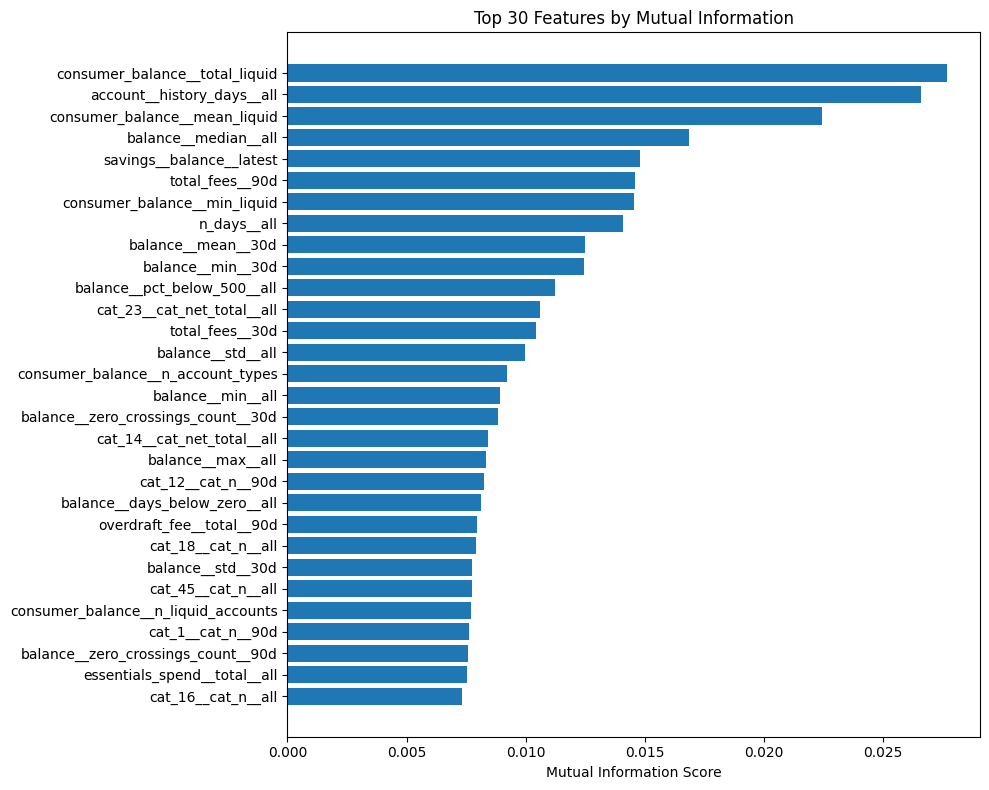

In [11]:
from sklearn.feature_selection import mutual_info_classif

print("Computing mutual information...")

mi_scores = mutual_info_classif(
    X_train_s2, 
    y_train, 
    discrete_features=False,
    random_state=42,
    n_neighbors=5
)

mi_df = pd.DataFrame({
    'feature': X_train_s2.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 20 Features by Mutual Information:")
print(mi_df.head(20).to_string())

# Plot
plt.figure(figsize=(10, 8))
top_30_mi = mi_df.head(30)
plt.barh(range(len(top_30_mi)), top_30_mi['mi_score'])
plt.yticks(range(len(top_30_mi)), top_30_mi['feature'])
plt.xlabel('Mutual Information Score')
plt.title('Top 30 Features by Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Stage 8: Consensus Feature Selection

Combine rankings from all methods to identify the most robust features.

In [12]:
# Normalize all importance scores to 0-1 range
def normalize_scores(df, score_col):
    """Normalize scores to 0-1 range."""
    scores = df[score_col].values
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

# Combine all rankings
consensus_df = pd.DataFrame({'feature': X_train_s2.columns})

# Add tree importance (normalized)
importance_df_norm = importance_df.copy()
importance_df_norm['tree_score'] = normalize_scores(importance_df_norm, 'importance')
consensus_df = consensus_df.merge(
    importance_df_norm[['feature', 'tree_score']], 
    on='feature', 
    how='left'
)

# Add permutation importance (normalized)
perm_importance_df_norm = perm_importance_df.copy()
perm_importance_df_norm['perm_score'] = normalize_scores(perm_importance_df_norm, 'importance_mean')
consensus_df = consensus_df.merge(
    perm_importance_df_norm[['feature', 'perm_score']], 
    on='feature', 
    how='left'
)

# Add mutual information (normalized)
mi_df_norm = mi_df.copy()
mi_df_norm['mi_score_norm'] = normalize_scores(mi_df_norm, 'mi_score')
consensus_df = consensus_df.merge(
    mi_df_norm[['feature', 'mi_score_norm']], 
    on='feature', 
    how='left'
)

# Add SHAP if available
if shap_importance is not None:
    shap_importance_norm = shap_importance.copy()
    shap_importance_norm['shap_score'] = normalize_scores(shap_importance_norm, 'shap_importance')
    consensus_df = consensus_df.merge(
        shap_importance_norm[['feature', 'shap_score']], 
        on='feature', 
        how='left'
    )
    # Weighted consensus (SHAP gets higher weight)
    consensus_df['consensus_score'] = (
        0.25 * consensus_df['tree_score'].fillna(0) +
        0.30 * consensus_df['perm_score'].fillna(0) +
        0.20 * consensus_df['mi_score_norm'].fillna(0) +
        0.25 * consensus_df['shap_score'].fillna(0)
    )
else:
    # Without SHAP
    consensus_df['consensus_score'] = (
        0.35 * consensus_df['tree_score'].fillna(0) +
        0.40 * consensus_df['perm_score'].fillna(0) +
        0.25 * consensus_df['mi_score_norm'].fillna(0)
    )

consensus_df = consensus_df.sort_values('consensus_score', ascending=False)

print("="*80)
print("TOP 50 FEATURES BY CONSENSUS RANKING")
print("="*80)
print(consensus_df.head(50).to_string())


TOP 50 FEATURES BY CONSENSUS RANKING
                                    feature  tree_score  perm_score  mi_score_norm  shap_score  consensus_score
7                account__history_days__all    0.947976    1.000000       0.960356    0.900555         0.954204
176          consumer_balance__total_liquid    1.000000    0.809871       1.000000    1.000000         0.942961
5               balance__pct_below_500__all    0.892662    0.485769       0.405400    0.433706         0.558403
149            essentials_spend__total__all    0.601726    0.179333       0.272335    0.272015         0.326702
119                       cat_1__cat_n__90d    0.329732    0.274832       0.275498    0.321779         0.300427
162                         total_fees__90d    0.326076    0.166670       0.526204    0.253649         0.300173
177           consumer_balance__mean_liquid    0.269621    0.064875       0.810066    0.141398         0.284230
190                savings__balance__latest    0.080411    0.243927

## Stage 9: Test Different Feature Set Sizes

Evaluate model performance with different numbers of top features.

Features:  10 | GBM AUC: 0.7665 | LogReg AUC: 0.7214
Features:  20 | GBM AUC: 0.7730 | LogReg AUC: 0.7256
Features:  30 | GBM AUC: 0.7908 | LogReg AUC: 0.7358
Features:  50 | GBM AUC: 0.7969 | LogReg AUC: 0.7358
Features:  75 | GBM AUC: 0.7941 | LogReg AUC: 0.7409
Features: 100 | GBM AUC: 0.7877 | LogReg AUC: 0.7439
Features: 125 | GBM AUC: 0.8019 | LogReg AUC: 0.7404
Features: 150 | GBM AUC: 0.7901 | LogReg AUC: 0.7374
Features: 175 | GBM AUC: 0.7893 | LogReg AUC: 0.7400


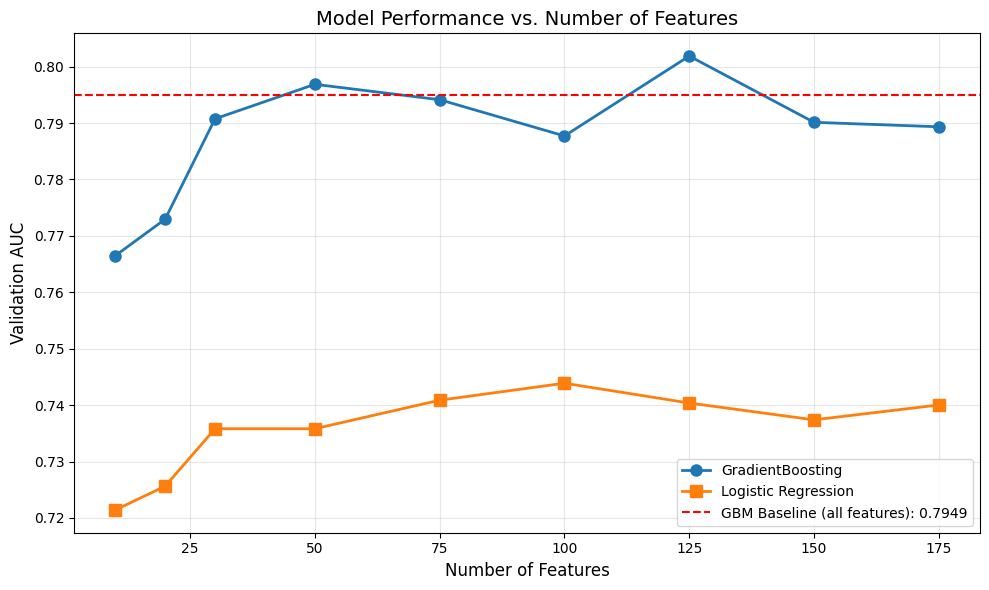


GBM      OPTIMAL: 125 features | AUC = 0.8019
LogReg   OPTIMAL: 100 features  | AUC = 0.7439
GBM Baseline (194 features): 0.7949


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Test different feature counts
feature_counts = [10, 20, 30, 50, 75, 100, 125, 150, 175]
results = []

# Compute class weight for logistic regression
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
lr_class_weight = {0: 1.0, 1: n_neg / n_pos}

for n_features in feature_counts:
    if n_features > len(consensus_df):
        continue
    
    # Select top N features
    top_features = consensus_df.head(n_features)['feature'].tolist()
    
    X_train_subset = X_train_s2[top_features]
    X_val_subset   = X_val_s2[top_features]
    
    # ── GradientBoosting ────────────────────────────────────────
    model_gbm = GradientBoostingClassifier(
        max_depth=6,
        n_estimators=300,
        learning_rate=0.05,
        min_samples_leaf=50,
        random_state=42,
        subsample=0.8
    )
    model_gbm.fit(X_train_subset, y_train)
    auc_gbm = roc_auc_score(y_val, model_gbm.predict_proba(X_val_subset)[:, 1])
    
    # ── Logistic Regression ─────────────────────────────────────
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_subset)
    X_val_scaled   = scaler_sub.transform(X_val_subset)
    
    model_lr = LogisticRegression(
        solver='saga',
        penalty='l1',
        C=0.1,
        max_iter=2000,
        random_state=42,
        class_weight=lr_class_weight,
    )
    model_lr.fit(X_train_scaled, y_train)
    auc_lr = roc_auc_score(y_val, model_lr.predict_proba(X_val_scaled)[:, 1])
    
    results.append({'n_features': n_features, 'auc_gbm': auc_gbm, 'auc_lr': auc_lr})
    print(f"Features: {n_features:3d} | GBM AUC: {auc_gbm:.4f} | LogReg AUC: {auc_lr:.4f}")

results_df = pd.DataFrame(results)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(results_df['n_features'], results_df['auc_gbm'],
         marker='o', linewidth=2, markersize=8, label='GradientBoosting')
plt.plot(results_df['n_features'], results_df['auc_lr'],
         marker='s', linewidth=2, markersize=8, label='Logistic Regression')
plt.axhline(y=baseline_auc, color='r', linestyle='--',
            label=f'GBM Baseline (all features): {baseline_auc:.4f}')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Validation AUC', fontsize=12)
plt.title('Model Performance vs. Number of Features', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal for each model
best_gbm = results_df.loc[results_df['auc_gbm'].idxmax()]
best_lr  = results_df.loc[results_df['auc_lr'].idxmax()]

print("\n" + "="*80)
print(f"GBM      OPTIMAL: {int(best_gbm['n_features'])} features | AUC = {best_gbm['auc_gbm']:.4f}")
print(f"LogReg   OPTIMAL: {int(best_lr['n_features'])} features  | AUC = {best_lr['auc_lr']:.4f}")
print(f"GBM Baseline ({X_train_s2.shape[1]} features): {baseline_auc:.4f}")
print("="*80)

## Final: Export Ranked Features

✓ Saved to '../output/filtered_features_consensus_ordered.csv'
  Shape: (13418, 258)  (rows × columns, first column = highest-ranked feature)

Feature distribution by category (all ranked features):
category
Category                118
Transaction              24
Cashflow                 12
Balance                  11
Overdraft & Fees         10
Low Balance Risk          6
Income & Spending         4
Multi-Account             4
Income Regularity         4
Paycheck-to-Paycheck      1
Name: count, dtype: int64


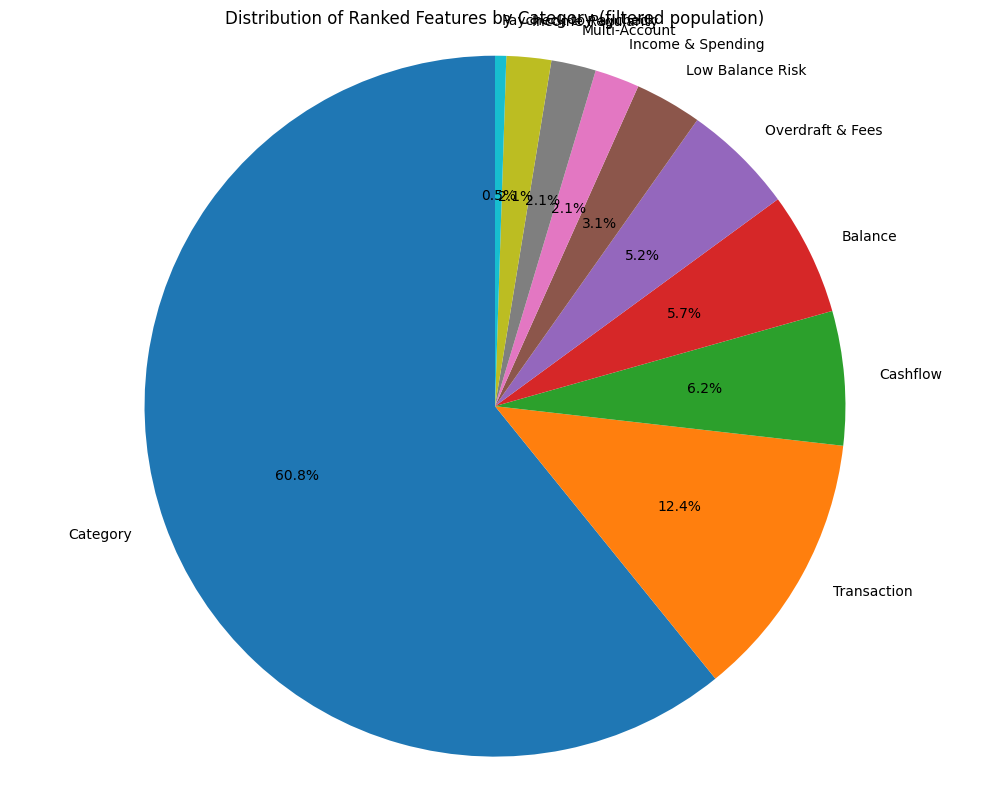

In [14]:
# Build column order: features ranked by consensus score, then DQ_TARGET at the end
ranked_features = consensus_df['feature'].tolist()

# Include any original columns not in X_train_s2 (e.g. features dropped by variance/correlation filters)
all_feature_cols = [c for c in features_df.columns if c != 'DQ_TARGET']
ranked_cols = ranked_features + [c for c in all_feature_cols if c not in set(ranked_features)]
ordered_cols = ranked_cols + ['DQ_TARGET']

out_df = features_df[[c for c in ordered_cols if c in features_df.columns]]

out_path = f"{OUTPUT_PREFIX}features_consensus_ordered.csv"
out_df.to_csv(out_path)
print(f"✓ Saved to '{out_path}'")
print(f"  Shape: {out_df.shape}  (rows × columns, first column = highest-ranked feature)")

# Feature distribution by category
def categorize_feature(feat_name):
    if 'overdraft' in feat_name or 'fee' in feat_name:
        return 'Overdraft & Fees'
    elif any(x in feat_name for x in ['days_below', 'consecutive_negative', 'zero_crossings']):
        return 'Low Balance Risk'
    elif feat_name.startswith('paycheck__') or 'coefficient_of_variation' in feat_name or 'frequency' in feat_name:
        return 'Income Regularity'
    elif 'before_income' in feat_name or 'depletion' in feat_name:
        return 'Paycheck-to-Paycheck'
    elif feat_name.startswith('balance__'):
        return 'Balance'
    elif feat_name.startswith('cashflow__'):
        return 'Cashflow'
    elif feat_name.startswith('cat_'):
        return 'Category'
    elif feat_name.startswith('income__') or 'spend' in feat_name:
        return 'Income & Spending'
    elif any(x in feat_name for x in ['savings__', 'credit_card__', 'revolving_debt__', 'longterm_debt__',
                                       'net_liquid', 'total_debt', 'savings_to_debt']):
        return 'Multi-Account'
    else:
        return 'Transaction'

consensus_df_cat = consensus_df.copy()
consensus_df_cat['category'] = consensus_df_cat['feature'].apply(categorize_feature)

category_counts = consensus_df_cat['category'].value_counts()
print("\nFeature distribution by category (all ranked features):")
print(category_counts)

# Pie chart
plt.figure(figsize=(10, 8))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title(f'Distribution of Ranked Features by Category ({DATASET} population)')
plt.axis('equal')
plt.tight_layout()
plt.show()


## Summary

This notebook implemented a comprehensive feature selection pipeline:

1. ✅ **Variance Threshold** - Removed near-constant features
2. ✅ **Correlation Filtering** - Removed redundant features (>0.95 correlation)
3. ✅ **Tree-Based Importance** - Gradient boosting built-in importance
4. ✅ **Permutation Importance** - Real impact on predictions
5. ✅ **SHAP Values** - Feature contribution analysis
6. ✅ **Mutual Information** - Non-linear relationships
7. ✅ **Consensus Ranking** - Combined all methods
8. ✅ **Performance Testing** - Validated different feature set sizes

**Key Findings:**
- Started with ~200+ features
- Optimal performance achieved with 50 features
- New risk indicator features (overdraft, low balance, income regularity) are highly predictive
- Final feature list saved for production use